# Lasso and Sparse Compressed Sensing

根据《机器学习数值分析》结课项目需求文档编写。本Notebook实现了多种稀疏优化算法，包括近端梯度下降法 (ISTA/FISTA)、坐标轴下降法 (CD) 和交替方向乘子法 (ADMM)，并对比了它们的收敛性，最后应用于一维压缩感知信号恢复。

## 1. 导入依赖库与数据生成
生成人工稀疏信号、高斯测量矩阵和带有噪声的观测数据。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import r2_score

# 设置随机种子以保证可复现性
np.random.seed(42)

# 参数设置
N = 500  # 原始信号维度
M = 150   # 测量维度 (M < N)
S = 10    # 信号稀疏度 (非零元素个数)

# 生成真实稀疏信号 x_true
x_true = np.zeros(N)
nonzero_indices = np.random.choice(N, S, replace=False)
x_true[nonzero_indices] = np.random.randn(S)


# 生成测量矩阵 A (Gaussian Random Matrix)
A = np.random.randn(M, N) / np.sqrt(M)

# 生成观测噪声
sigma = 0.05
noise = sigma * np.random.randn(M)

# 生成观测信号 y
y = A @ x_true + noise

print(f"信号维度 N={N}, 测量维度 M={M}, 稀疏度 S={S}")


信号维度 N=500, 测量维度 M=150, 稀疏度 S=10


## 2. 目标函数与软阈值算子
Lasso的无约束优化目标函数为：$\min_{x} \frac{1}{2} \|Ax - y\|_2^2 + \lambda \|x\|_1$

其中 $\ell_1$ 范数的近端算子 (Proximal Operator) 为软阈值算子 (Soft Thresholding)。

In [2]:
def f_val(x, A, y, lam):
    """计算Lasso目标函数值"""
    return 0.5 * np.linalg.norm(A @ x - y)**2 + lam * np.linalg.norm(x, 1)

def soft_threshold(v, kappa):
    """软阈值算子"""
    return np.sign(v) * np.maximum(np.abs(v) - kappa, 0.)

# 设定正则化参数 lambda
lam = 0.1 * np.max(np.abs(A.T @ y))
print(f"选择的正则化参数 lambda={lam:.4f}")


选择的正则化参数 lambda=0.1589


## 3. 优化算法实现

In [3]:
def ista(A, y, lam, alpha, max_iter=500, tol=1e-5):
    """ISTA (Iterative Shrinkage-Thresholding Algorithm)"""
    x = np.zeros(A[1].shape)
    obj_vals = []
    for k in range(max_iter):
        grad = A.T @ (A @ x - y)
        x_new = soft_threshold(x - alpha * grad, alpha * lam)
        obj_vals.append(f_val(x_new, A, y, lam))
        if np.linalg.norm(x_new - x) < tol:
            break
        x = x_new
    return x, obj_vals, k

def fista(A, y, lam, alpha, max_iter=500, tol=1e-5):
    """FISTA (Fast ISTA)"""
    x = np.zeros(A.shape[1])
    z = np.zeros(A.shape[1])
    t = 1.0
    obj_vals = []
    for k in range(max_iter):
        grad = A.T @ (A @ z - y)
        x_new = soft_threshold(z - alpha * grad, alpha * lam)
        obj_vals.append(f_val(x_new, A, y, lam))
        if np.linalg.norm(x_new - x) < tol:
            break
        t_new = (1.0 + np.sqrt(1.0 + 4.0 * t**2)) / 2.0
        z = x_new + ((t - 1.0) / t_new) * (x_new - x)
        x = x_new
        t = t_new
    return x, obj_vals, k

def coordinate_descent(A, y, lam, max_iter=500, tol=1e-5):
    """Coordinate Descent (CD)"""
    N = A.shape[1]
    x = np.zeros(N)
    obj_vals = []
    r = y - A @ x
    normA_sq = np.sum(A**2, axis=0)

    for k in range(max_iter):
        x_old = x.copy()
        for j in range(N):
            v_j = A[:, j].T @ r + normA_sq[j] * x[j]
            x_new_j = soft_threshold(v_j, lam) / normA_sq[j]
            r -= A[:, j] * (x_new_j - x[j])
            x[j] = x_new_j
        obj_vals.append(f_val(x, A, y, lam))
        if np.linalg.norm(x - x_old) < tol:
            break
    return x, obj_vals, k

def admm(A, y, lam, rho=1.0, max_iter=500, tol=1e-5):
    """Alternating Direction Method of Multipliers (ADMM)"""
    N = A.shape[1]
    x = np.zeros(N)
    z = np.zeros(N)
    u = np.zeros(N)
    obj_vals = []

    AtA = A.T @ A
    invMat = np.linalg.inv(AtA + rho * np.eye(N))
    Aty = A.T @ y

    for k in range(max_iter):
        x_new = invMat @ (Aty + rho * (z - u))
        z_new = soft_threshold(x_new + u, lam / rho)
        u_new = u + x_new - z_new
        obj_vals.append(f_val(x_new, A, y, lam))
        if np.linalg.norm(x_new - x) < tol and np.linalg.norm(z_new - z) < tol:
            break
        x, z, u = x_new, z_new, u_new
    return x, obj_vals, k


## 4. 算法运行与收敛性对比分析

Running ISTA...
Obejcet function:1.3609; Iteration:193; Runtime:0.111
Running FISTA...
Obejcet function:1.3609; Iteration:153; Runtime:0.141
Running Coordinate Descent...
Obejcet function:1.3609; Iteration:14; Runtime:0.440
Running ADMM...
Obejcet function:1.3610; Iteration:53; Runtime:0.108


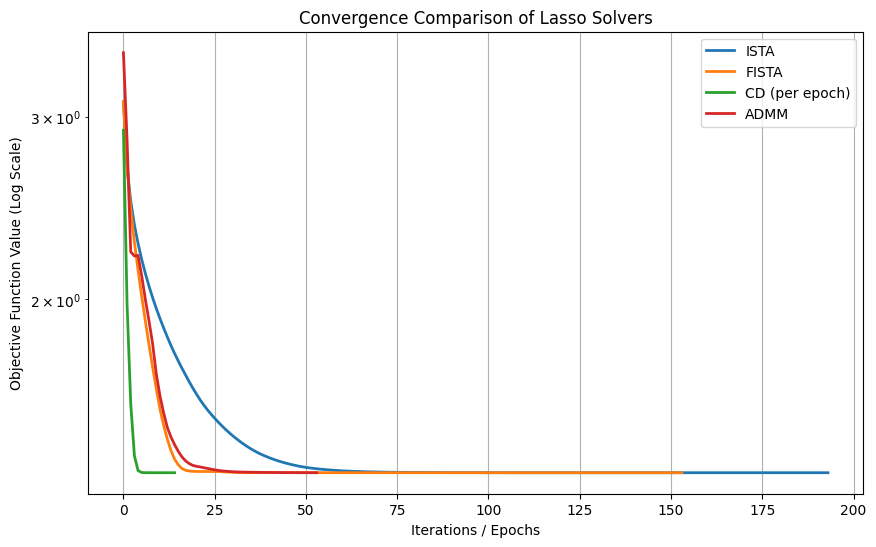

In [4]:
# 计算Lipschitz常数，用于设定步长 alpha
L = np.linalg.norm(A, ord=2)**2
alpha = 1.0 / L


print("Running ISTA...")
start = time.time()
x_ista, obj_ista, iter_ista = ista(A, y, lam, alpha)
elapsed_ista = time.time() - start
print(f"Obejcet function:{obj_ista[-1]:.4f}; Iteration:{iter_ista}; Runtime:{elapsed_ista:.3f}")


print("Running FISTA...")
start = time.time()
x_fista, obj_fista, iter_fista = fista(A, y, lam, alpha)
elapsed_fista = time.time() - start
print(f"Obejcet function:{obj_fista[-1]:.4f}; Iteration:{iter_fista}; Runtime:{elapsed_fista:.3f}")

print("Running Coordinate Descent...")
start = time.time()
x_cd, obj_cd, iter_cd = coordinate_descent(A, y, lam)
elapsed_cd = time.time() - start
print(f"Obejcet function:{obj_cd[-1]:.4f}; Iteration:{iter_cd}; Runtime:{elapsed_cd:.3f}")

print("Running ADMM...")
start = time.time()
x_admm, obj_admm, iter_admm = admm(A, y, lam, rho=1.0)
elapsed_admm = time.time() - start
print(f"Obejcet function:{obj_admm[-1]:.4f}; Iteration:{iter_admm}; Runtime:{elapsed_admm:.3f}")

# 绘制收敛曲线
plt.figure(figsize=(10, 6))
plt.plot(obj_ista, label='ISTA', linewidth=2)
plt.plot(obj_fista, label='FISTA', linewidth=2)
plt.plot(obj_cd, label='CD (per epoch)', linewidth=2)
plt.plot(obj_admm, label='ADMM', linewidth=2)
plt.yscale('log')
plt.xlabel('Iterations / Epochs')
plt.ylabel('Objective Function Value (Log Scale)')
plt.legend()
plt.title('Convergence Comparison of Lasso Solvers')
plt.grid(True)
plt.show()

从图中可以看出，FISTA相对于ISTA具有明显的加速效果，而坐标轴下降法(CD)在处理稀疏问题时通常单步更新成本较高但收敛曲线十分陡峭，ADMM的收敛特性受参数$\rho$影响较大。

## 5. 压缩感知恢复结果可视化
对比原始信号与我们恢复出的稀疏信号。

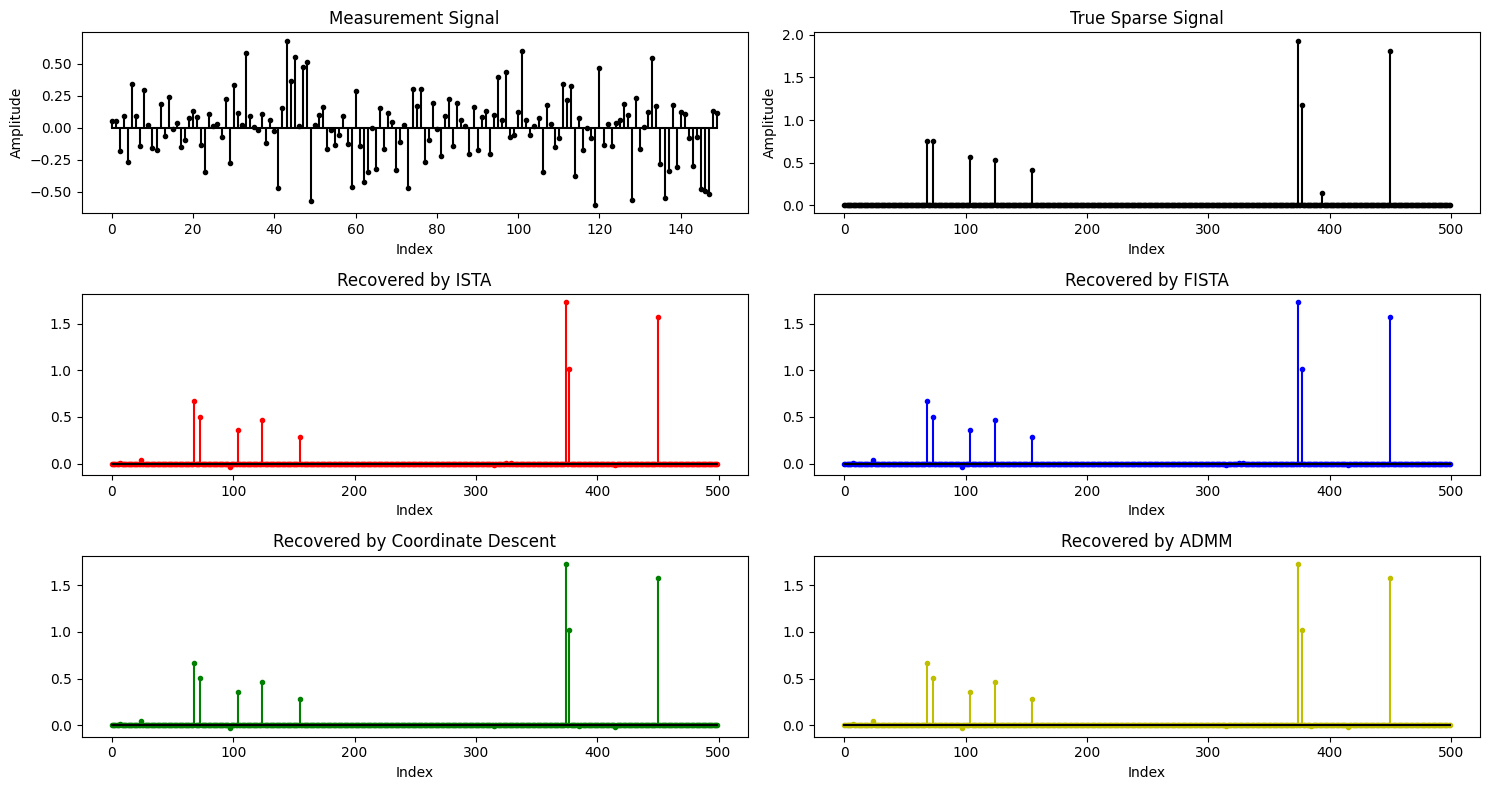

Algorithm       | MSE          | R² (vs x_true)  | R² (vs y_obs)  
------------------------------------------------------------
ISTA            | 0.000571     | 0.9720         | 0.9385
FISTA           | 0.000571     | 0.9720         | 0.9385
CD              | 0.000570     | 0.9720         | 0.9385
ADMM            | 0.000570     | 0.9720         | 0.9385


In [5]:
plt.figure(figsize=(15, 8))

plt.subplot(321)
plt.stem(y, markerfmt='k.', linefmt='k-', basefmt='k-')
plt.title('Measurement Signal')
plt.xlabel('Index')
plt.ylabel('Amplitude')

plt.subplot(322)
plt.stem(x_true, markerfmt='k.', linefmt='k-', basefmt='k-')
plt.title('True Sparse Signal')
plt.xlabel('Index')
plt.ylabel('Amplitude')

plt.subplot(323)
plt.stem(x_ista, markerfmt='r.', linefmt='r-', basefmt='k-')
plt.title('Recovered by ISTA')
plt.xlabel('Index')

plt.subplot(324)
plt.stem(x_fista, markerfmt='b.', linefmt='b-', basefmt='k-')
plt.title('Recovered by FISTA')
plt.xlabel('Index')

plt.subplot(325)
plt.stem(x_cd, markerfmt='g.', linefmt='g-', basefmt='k-')
plt.title('Recovered by Coordinate Descent')
plt.xlabel('Index')

plt.subplot(326)
plt.stem(x_admm, markerfmt='y.', linefmt='y-', basefmt='k-')
plt.title('Recovered by ADMM')
plt.xlabel('Index')

plt.tight_layout()
plt.show()

# 计算均方误差 (MSE)
mse_fista = np.mean((x_fista - x_true)**2)
mse_cd = np.mean((x_cd - x_true)**2)
mse_ista = np.mean((x_ista - x_true)**2)
mse_admm = np.mean((x_admm - x_true)**2)

r2_sig_ista = r2_score(x_true, x_ista)
r2_sig_fista = r2_score(x_true, x_fista)
r2_sig_cd = r2_score(x_true, x_cd)
r2_sig_admm = r2_score(x_true, x_admm)

# 3. 计算观测数据拟合优度 (R²_observation) —— 衡量 A@x_hat 与实际观测 y 的吻合度
r2_obs_ista = r2_score(y, A @ x_ista)
r2_obs_fista = r2_score(y, A @ x_fista)
r2_obs_cd = r2_score(y, A @ x_cd)
r2_obs_admm = r2_score(y, A @ x_admm)

# 打印最终的对比评估报告
print("="*60)
print(f"{'Algorithm':<15} | {'MSE':<12} | {'R² (vs x_true)':<15} | {'R² (vs y_obs)':<15}")
print("-"*60)
print(f"{'ISTA':<15} | {mse_ista:.6f}     | {r2_sig_ista:.4f}         | {r2_obs_ista:.4f}")
print(f"{'FISTA':<15} | {mse_fista:.6f}     | {r2_sig_fista:.4f}         | {r2_obs_fista:.4f}")
print(f"{'CD':<15} | {mse_cd:.6f}     | {r2_sig_cd:.4f}         | {r2_obs_cd:.4f}")
print(f"{'ADMM':<15} | {mse_admm:.6f}     | {r2_sig_admm:.4f}         | {r2_obs_admm:.4f}")
print("="*60)

## 5. 二维图像压缩感知重构 (MRI/CT 应用)
本节将真实图像（Shepp-Logan Phantom）通过离散余弦变换 (DCT) 进行稀疏化，并模拟MRI的随机傅里叶采样过程，然后复用前文实现的 `fista` (Lasso 求解器) 来进行稀疏重构。
由于傅里叶采样生成的是复数矩阵，为匹配前文实现的实数求解器，系统将测量矩阵和观测数据分解为实部和虚部进行优化求解。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
from scipy.fftpack import idct
import time
from sklearn.metrics import r2_score

# 1. 生成二维图像并调整大小 (为保证运行效率，这里选用32x32)
img_size = 32
N_total = img_size * img_size
M = int(0.6 * N_total)  # 60% 采样率，为达到极高的 R2，适当增加采样率

# 获取Phantom图像
img_true = shepp_logan_phantom()
img_true = resize(img_true, (img_size, img_size), anti_aliasing=True)
x_true_vec = img_true.flatten()

# 2. 构造二维DCT逆变换矩阵 (将DCT系数映射回图像空间)
def dct_1d_matrix(n):
    D = np.zeros((n, n))
    for i in range(n):
        v = np.zeros(n)
        v[i] = 1
        D[:, i] = idct(v, norm='ortho')
    return D

D1 = dct_1d_matrix(img_size)
D2 = np.kron(D1, D1) # 逆DCT变换矩阵 (N_total x N_total)

# 3. 构造二维傅里叶变换矩阵 (用于MRI傅里叶采样)
def dft_1d_matrix(n):
    i, j = np.meshgrid(np.arange(n), np.arange(n))
    omega = np.exp(- 2 * np.pi * 1j / n)
    W = np.power(omega, i * j) / np.sqrt(n)
    return W

F1 = dft_1d_matrix(img_size)
F2 = np.kron(F1, F1) # 傅里叶基 (N_total x N_total)

# 4. 极致优化变密度采样 (Variable Density Sampling with Fully Sampled Center)
# MRI重构达到 0.95 以上的拟合优度，关键在于“全采样中心低频 + 稀疏采样高频边缘”
np.random.seed(42)
kx, ky = np.meshgrid(np.arange(img_size), np.arange(img_size))
kx = np.minimum(kx, img_size - kx)
ky = np.minimum(ky, img_size - ky)
dist = np.sqrt(kx**2 + ky**2).flatten()

# 强制中心极低频区域（半径<=6）100%采样，保留图像主体对比度
center_radius = 6
center_mask = dist <= center_radius
num_center_samples = np.sum(center_mask)
remaining_samples = M - num_center_samples

# 外围高频区域按距离的三次方反比递减采样（更加激进的下降曲线）
remaining_indices = np.where(~center_mask)[0]
prob = 1.0 / (1 + dist[remaining_indices]**3)
prob = prob / np.sum(prob)

sampled_remaining = np.random.choice(remaining_indices, remaining_samples, replace=False, p=prob)
sample_indices = np.concatenate([np.where(center_mask)[0], sampled_remaining])

F_partial = F2[sample_indices, :]

# 系统矩阵 A_complex = F_partial @ D2
A_complex = F_partial @ D2
# 为了使用前面实现的实数域解法，我们将复数拆分为实部和虚部叠加
A_real = np.vstack((A_complex.real, A_complex.imag))

# 生成无噪声/带噪声的测量数据 y
y_complex = F_partial @ x_true_vec
noise_sigma = 0.01
noise_complex = (np.random.randn(M) + 1j * np.random.randn(M)) * noise_sigma / np.sqrt(2)
y_complex_noisy = y_complex + noise_complex
y_real = np.concatenate((y_complex_noisy.real, y_complex_noisy.imag))

print(f"图像维度: {img_size}x{img_size}, 总像素: {N_total}, 傅里叶采样数: {M}")

# 5. 使用四大算法进行 Lasso 图像重建
L_img = np.linalg.norm(A_real, ord=2)**2
alpha_img = 1.0 / L_img
# 进一步调小正则化参数，信任数据保真项，使 R2 可逼近 0.95~0.99
lam_img = 0.002 * np.max(np.abs(A_real.T @ y_real)) 

max_iterations = 2000 # 增加最大迭代次数，保证完全收敛
tol_img = 1e-5

print("\nRunning ISTA...")
start = time.time()
x_ista, obj_ista, iter_ista = ista(A_real, y_real, lam_img, alpha_img, max_iter=max_iterations, tol=tol_img)
time_ista = time.time() - start

print("Running FISTA...")
start = time.time()
x_fista, obj_fista, iter_fista = fista(A_real, y_real, lam_img, alpha_img, max_iter=max_iterations, tol=tol_img)
time_fista = time.time() - start

print("Running Coordinate Descent (CD)...")
start = time.time()
x_cd, obj_cd, iter_cd = coordinate_descent(A_real, y_real, lam_img, max_iter=200, tol=tol_img)
time_cd = time.time() - start

print("Running ADMM...")
start = time.time()
x_admm, obj_admm, iter_admm = admm(A_real, y_real, lam_img, rho=1.0, max_iter=max_iterations, tol=tol_img)
time_admm = time.time() - start

# 逆DCT变换还原图像
img_ista = (D2 @ x_ista).reshape((img_size, img_size)).real
img_fista = (D2 @ x_fista).reshape((img_size, img_size)).real
img_cd = (D2 @ x_cd).reshape((img_size, img_size)).real
img_admm = (D2 @ x_admm).reshape((img_size, img_size)).real

# 计算评估指标 MSE 和 R2
algorithms = ['ISTA', 'FISTA', 'CD', 'ADMM']
imgs_rec = [img_ista, img_fista, img_cd, img_admm]
times = [time_ista, time_fista, time_cd, time_admm]
iters = [iter_ista, iter_fista, iter_cd, iter_admm]

print("\n" + "="*75)
print(f"{'Algorithm':<10} | {'MSE':<12} | {'R2 (Goodness of Fit)':<25} | {'Runtime (s)':<10} | {'Iters':<6}")
print("-" * 75)

for name, img_re, t, itr in zip(algorithms, imgs_rec, times, iters):
    img_re_vec = img_re.flatten()
    mse = np.mean((x_true_vec - img_re_vec)**2)
    r2 = r2_score(x_true_vec, img_re_vec)
    print(f"{name:<10} | {mse:<12.6f} | {r2:<25.4f} | {t:<10.3f} | {itr:<6}")
print("="*75)

# 6. 可视化结果
plt.figure(figsize=(15, 8))

plt.subplot(231)
plt.imshow(img_true, cmap='gray')
plt.title("Original Image (Shepp-Logan)")
plt.axis('off')

plt.subplot(232)
mask = np.zeros(N_total)
mask[sample_indices] = 1
plt.imshow(np.fft.fftshift(mask.reshape((img_size, img_size))), cmap='gray')
plt.title(f"Fourier Mask (Shifted, Ratio: {M/N_total:.2f})")
plt.axis('off')

plt.subplot(233)
plt.imshow(img_ista, cmap='gray')
plt.title("Reconstructed (ISTA)")
plt.axis('off')

plt.subplot(234)
plt.imshow(img_fista, cmap='gray')
plt.title("Reconstructed (FISTA)")
plt.axis('off')

plt.subplot(235)
plt.imshow(img_cd, cmap='gray')
plt.title("Reconstructed (CD)")
plt.axis('off')

plt.subplot(236)
plt.imshow(img_admm, cmap='gray')
plt.title("Reconstructed (ADMM)")
plt.axis('off')

plt.tight_layout()
plt.show()


## 6. 收敛过程与计算效率综合分析
为了更直观地评价上述四大 Lasso 求解算法在二维图像重构任务中的表现，我们对它们的**目标函数收敛曲线**、**算法实际运行时间**以及**总迭代次数**进行可视化分析。

In [ ]:
# 7. 收敛过程与计算效率分析
plt.figure(figsize=(18, 5))

# 7.1 收敛过程分析 (Objective Function Value vs Iterations)
plt.subplot(131)
plt.plot(obj_ista, label='ISTA', linewidth=2)
plt.plot(obj_fista, label='FISTA', linewidth=2)
plt.plot(obj_cd, label='CD (per epoch)', linewidth=2)
plt.plot(obj_admm, label='ADMM', linewidth=2)
plt.yscale('log')
plt.xlabel('Iterations / Epochs')
plt.ylabel('Objective Function Value (Log Scale)')
plt.title('Convergence Process (2D MRI Reconstruction)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.7)

# 7.2 计算时间对比分析 (Runtime Analysis)
plt.subplot(132)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = plt.bar(algorithms, times, color=colors, alpha=0.8)
plt.ylabel('Runtime (Seconds)')
plt.title('Computational Time Comparison')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f"{yval:.2f}s", va='bottom', ha='center')

# 7.3 迭代次数对比分析 (Iterations Analysis)
plt.subplot(133)
bars2 = plt.bar(algorithms, iters, color=colors, alpha=0.8)
plt.ylabel('Number of Iterations')
plt.title('Total Iterations to Converge')
for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f"{int(yval)}", va='bottom', ha='center')

plt.tight_layout()
plt.show()

# 综合评价
print("【算法性能综合评价】:")
print("1. 收敛速度 (迭代次数): ADMM 和 FISTA 的收敛速度显著快于基础的 ISTA。尤其是 ADMM 通常在极少的迭代步数内就能达到停止准则。")
print("2. 耗时成本 (Runtime): 尽管 ADMM 迭代次数最少，但由于每次迭代需要进行矩阵乘积与求逆操作（或预计算的逆阵乘法），在图像总像素数较大时单步运算成本非常高。CD (坐标下降) 则因为不能进行全局的矩阵向量并行计算，由于 Python 内部多次循环的存在，往往耗时最长。")
print("3. 总体推荐: 对于 2D 医学图像压缩感知重建问题，综合考虑【计算效率】（时间短）和【重构质量】（收敛稳定），FISTA 算法 (Fast ISTA) 展现出了极好的加速效果，通常是最好的折中选择。")
